In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from pathlib import Path

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def display_df(df):
    pd.set_option("display.max_rows", None)     
    pd.set_option("display.max_columns", None) 
    pd.set_option("display.width", None)       

    with pd.option_context("display.max_rows", None):
        display(df)

    pd.reset_option("display.max_rows")
    pd.reset_option("display.max_columns")
    pd.reset_option("display.width")

def randomize_pair(df):
    """
    Randomly swap red (r_*) and blue (b_*) fighter columns for each row to prevent ordering bias.
    For each row, with 50% probability, swaps all r_* and b_* column pairs and flips the winner label.
    
    This ensures the model doesn't learn positional bias (e.g., always predicting red wins).
    """
    df_swapped = df.copy()
    
    # Get all r_* and b_* column pairs
    r_cols = sorted([col for col in df.columns if col.startswith('r_')])
    b_cols = sorted([col for col in df.columns if col.startswith('b_')])
    
    # Create mapping: r_col -> corresponding b_col
    col_pairs = {}
    for r_col in r_cols:
        b_col = r_col.replace('r_', 'b_', 1)
        if b_col in b_cols:
            col_pairs[r_col] = b_col
    
    # Randomly decide which rows to swap (50% chance per row)
    np.random.seed(None)  # Use random seed for each call
    swap_mask = np.random.rand(len(df)) > 0.5
    
    # Swap all column pairs for rows where swap_mask is True
    for r_col, b_col in col_pairs.items():
        # Store values before swapping
        r_values = df_swapped[r_col].values.copy()
        b_values = df_swapped[b_col].values.copy()
        
        # Swap where mask is True
        df_swapped.loc[swap_mask, r_col] = b_values[swap_mask]
        df_swapped.loc[swap_mask, b_col] = r_values[swap_mask]
    
    # Flip winner label: 'r' -> 'b', 'b' -> 'r' for swapped rows
    if 'winner' in df_swapped.columns:
        # Ensure winner is string type
        df_swapped['winner'] = df_swapped['winner'].astype(str).str.strip().str.lower()
        
        # Create a copy for safe swapping
        winner_values = df_swapped['winner'].values.copy()
        
        # Swap winner labels where rows were swapped
        r_wins = (winner_values == 'r') & swap_mask
        b_wins = (winner_values == 'b') & swap_mask
        
        winner_values[r_wins] = 'b'
        winner_values[b_wins] = 'r'
        
        df_swapped['winner'] = winner_values
    
    return df_swapped

In [3]:
data_path = Path("data") / "archive" / "UFC.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Could not find {data_path.resolve()}")

columns_to_keep = [
    'r_id',
    'b_id', 
    'r_wins',
    'b_wins',
    'r_losses',
    'b_losses',
    'r_draws',
    'b_draws',
    'b_height',
    'r_height',
    'b_reach',
    'r_reach',
    'b_stance',
    'r_stance',
    'r_weight',
    'b_weight',
    'r_dob',
    'b_dob',
    'r_splm',
    'b_splm',
    'r_td_acc',
    'b_td_acc',    
    'r_str_acc',
    'b_str_acc',
    'r_sapm',
    'b_sapm',
    'r_str_def',
    'b_str_def',
    'r_td_avg',
    'b_td_avg',
    'r_td_avg_acc',
    'b_td_avg_acc',
    'r_td_def',
    'b_td_def',
    'r_sub_avg',
    'b_sub_avg',
    'division',
    'title_fight',
    'winner_id',
]

ufc_df = pd.read_csv(data_path)
ufc_df = ufc_df[columns_to_keep]

display_df(ufc_df.head())


,r_id,b_id,r_wins,b_wins,r_losses,b_losses,r_draws,b_draws,b_height,r_height,b_reach,r_reach,b_stance,r_stance,r_weight,b_weight,r_dob,b_dob,r_splm,b_splm,r_td_acc,b_td_acc,r_str_acc,b_str_acc,r_sapm,b_sapm,r_str_def,b_str_def,r_td_avg,b_td_avg,r_td_avg_acc,b_td_avg_acc,r_td_def,b_td_def,r_sub_avg,b_sub_avg,division,title_fight,winner_id
0,c2299ec916bc7c56,9c393e836a852f30,15,12,3,2,0,0,180.34,180.34,190.50,185.42,Orthodox,Southpaw,70.31,70.31,1995/12/18,1996/06/17,5.05,3.84,30.0,NaN,55,57,4.19,4.16,42,60,4.35,0.00,37,0,70,84,1.6,0.0,lightweight,0,c2299ec916bc7c56
1,881bf86d4cba8578,4126a78111c0855a,17,17,4,2,0,0,185.42,190.50,190.50,190.50,Southpaw,Orthodox,83.91,83.91,1996/03/01,1993/01/16,4.28,3.44,NaN,0.0,54,56,3.17,2.50,58,60,0.74,1.28,32,48,81,76,1.0,0.4,middleweight,0,881bf86d4cba8578
2,476fe566d2df676e,eabf206b162b3b83,19,17,6,10,0,1,190.50,190.50,193.04,193.04,Orthodox,Switch,92.99,92.99,1994/02/10,1987/11/27,3.32,2.50,NaN,0.0,43,45,3.93,3.04,51,43,0.30,1.43,66,18,80,35,0.1,1.3,light heavyweight,0,476fe566d2df676e
3,4bdedbdeedff7d1d,f6ad6a1e4d600e0d,10,17,3,2,0,0,177.80,177.80,187.96,185.42,Orthodox,Orthodox,70.31,70.31,1995/11/15,1995/04/26,6.59,5.71,0.0,100.0,44,41,5.15,4.47,61,50,1.01,4.17,60,55,66,81,0.0,0.2,lightweight,0,f6ad6a1e4d600e0d
4,1d2d98ddd05b38fb,f748267c4ab6c127,11,14,0,7,1,1,187.96,187.96,198.12,187.96,Orthodox,Southpaw,77.11,77.11,1997/09/17,1995/09/10,3.74,4.71,25.0,NaN,42,40,2.74,7.15,75,47,1.25,0.00,25,0,0,47,0.0,0.0,welterweight,0,1d2d98ddd05b38fb


In [4]:
desc_df = ufc_df.describe().T
desc_df["na_count"] = ufc_df.isna().sum()
display_df(desc_df)

,count,mean,std,min,25%,50%,75%,max,na_count
r_wins,8337.0,19.233297,9.264114,0.00,13.00,18.00,24.00,253.00,0
b_wins,8337.0,17.272160,9.016829,0.00,11.00,16.00,22.00,253.00,0
r_losses,8337.0,8.056735,4.691696,0.00,5.00,7.00,11.00,53.00,0
b_losses,8337.0,7.504138,4.492130,0.00,4.00,7.00,10.00,53.00,0
r_draws,8337.0,0.241214,0.604279,0.00,0.00,0.00,0.00,10.00,0
b_draws,8337.0,0.252849,0.696767,0.00,0.00,0.00,0.00,11.00,0
b_height,8316.0,178.460962,8.984635,152.40,172.72,177.80,185.42,210.82,21
r_height,8332.0,178.534076,9.044297,152.40,172.72,177.80,185.42,210.82,5
b_reach,7436.0,182.684615,10.791596,147.32,175.26,182.88,190.50,213.36,901
r_reach,7917.0,183.104580,10.949027,147.32,175.26,182.88,190.50,213.36,420


,feature,unique_categories
0,b_id,2450
1,b_dob,2038
2,r_id,1924
3,winner_id,1829
4,r_dob,1679
5,division,107
6,b_stance,5
7,r_stance,5


/var/folders/yj/3yq26dgs2nn76q3v6zwh32mc0000gn/T/ipykernel_68277/3908359429.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


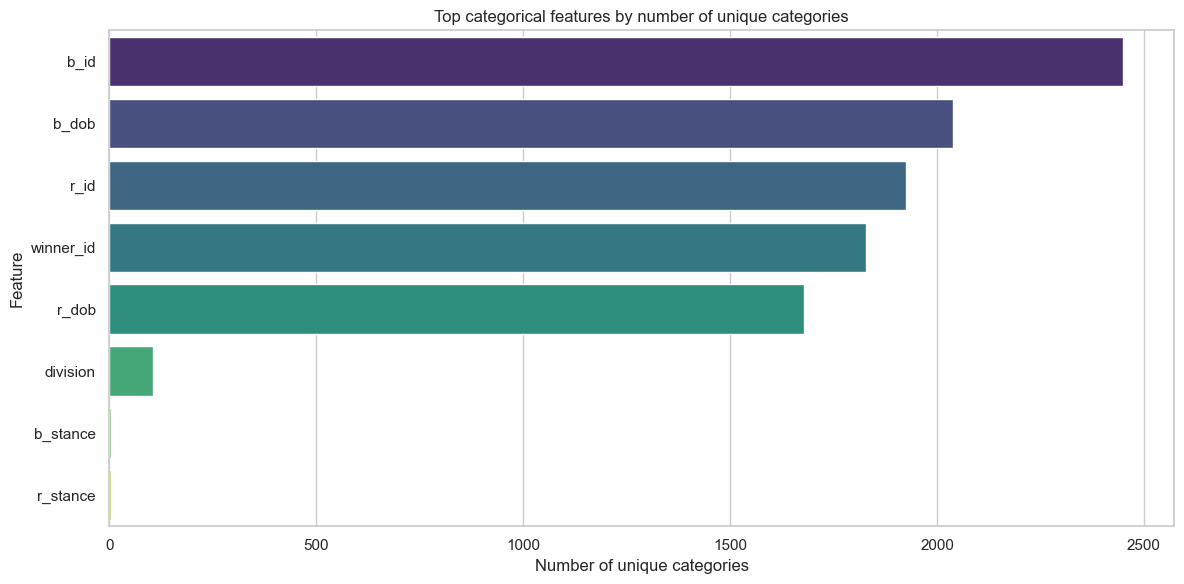

In [5]:
# Analyze categorical columns: number of distinct categories per feature
categorical_cols = ufc_df.select_dtypes(include=["object", "category"]).columns

cat_summary = (
    ufc_df[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "unique_categories"})
)

display(cat_summary)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=cat_summary.head(20),
    x="unique_categories",
    y="feature",
    palette="viridis"
)
plt.title("Top categorical features by number of unique categories")
plt.xlabel("Number of unique categories")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Feature Engineering

**Assumptions:** We will assume fights are the same across time for simplicity, so we will not consider the dates of fights. 

*Transformations*
- `r_dob` and `b_dob` (Date of Birth) to numerical `r_age` and `b_age` since age is likely an important feature
- `winner_id` to binary feature `winner` which will also be target label and drop `b_id` and `r_id`
- We will also only use the fighter's win-loss ratio. 
- I will only consider Orthodox and Southpaw and convert all other categories to orthodox since these are the common stances. 
- We will simplify further to drop `r_stance` and `b_stance` and make new feature `open_stance` for whether the fighters are in opposite stances or not.

In [6]:
# Parse date of birth strings (handles formats like "May 08, 1982" or "1995/12/18")
ufc_df['r_dob'] = pd.to_datetime(ufc_df['r_dob'], errors='coerce')
ufc_df['b_dob'] = pd.to_datetime(ufc_df['b_dob'], errors='coerce')

# Create winner column: 'r' if winner_id matches r_id, 'b' if it matches b_id
ufc_df['winner'] = ufc_df['winner_id'] == ufc_df['r_id']

# Calculate age at today's date (accurate age calculation)
today = pd.Timestamp.today()
ufc_df['r_age'] = ((today - ufc_df['r_dob']).dt.days / 365.25).round(2)
ufc_df['b_age'] = ((today - ufc_df['b_dob']).dt.days / 365.25).round(2)

ufc_df['r_win_loss_ratio'] = ufc_df['r_wins'] / (ufc_df['r_wins'] + ufc_df['r_losses'])
ufc_df['b_win_loss_ratio'] = ufc_df['b_wins'] / (ufc_df['b_wins'] + ufc_df['b_losses'])

# Normalize stance values: keep only 'Orthodox' and 'Southpaw', map everything else to 'Orthodox'
valid_stances = {"Orthodox", "Southpaw"}
ufc_df['r_stance'] = ufc_df['r_stance'].where(ufc_df['r_stance'].isin(valid_stances), 'Orthodox')
ufc_df['b_stance'] = ufc_df['b_stance'].where(ufc_df['b_stance'].isin(valid_stances), 'Orthodox')

ufc_df['open_stance'] = ufc_df['r_stance'] != ufc_df['b_stance']

# Drop columns no longer needed
ufc_df = ufc_df.drop(columns=['winner_id', 'division', 'r_stance', 'b_stance', 'r_dob', 'b_dob', 'r_id', 'b_id', 'r_wins', 'r_losses', 'b_wins', 'b_losses', 'r_draws', 'b_draws'])

display_df(ufc_df.head())

,b_height,r_height,b_reach,r_reach,r_weight,b_weight,r_splm,b_splm,r_td_acc,b_td_acc,r_str_acc,b_str_acc,r_sapm,b_sapm,r_str_def,b_str_def,r_td_avg,b_td_avg,r_td_avg_acc,b_td_avg_acc,r_td_def,b_td_def,r_sub_avg,b_sub_avg,title_fight,winner,r_age,b_age,r_win_loss_ratio,b_win_loss_ratio,open_stance
0,180.34,180.34,190.50,185.42,70.31,70.31,5.05,3.84,30.0,NaN,55,57,4.19,4.16,42,60,4.35,0.00,37,0,70,84,1.6,0.0,0,True,29.92,29.42,0.833333,0.857143,True
1,185.42,190.50,190.50,190.50,83.91,83.91,4.28,3.44,NaN,0.0,54,56,3.17,2.50,58,60,0.74,1.28,32,48,81,76,1.0,0.4,0,True,29.72,32.84,0.809524,0.894737,True
2,190.50,190.50,193.04,193.04,92.99,92.99,3.32,2.50,NaN,0.0,43,45,3.93,3.04,51,43,0.30,1.43,66,18,80,35,0.1,1.3,0,True,31.77,37.98,0.760000,0.629630,False
3,177.80,177.80,187.96,185.42,70.31,70.31,6.59,5.71,0.0,100.0,44,41,5.15,4.47,61,50,1.01,4.17,60,55,66,81,0.0,0.2,0,False,30.01,30.57,0.769231,0.894737,False
4,187.96,187.96,198.12,187.96,77.11,77.11,3.74,4.71,25.0,NaN,42,40,2.74,7.15,75,47,1.25,0.00,25,0,0,47,0.0,0.0,0,True,28.17,30.19,1.000000,0.666667,True


In [7]:
X = ufc_df.drop(columns=['winner'])
y = ufc_df['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

def clean_none_values(X):
    """Convert None values to NaN for proper imputation"""
    X = X.copy()
    # Replace None with NaN for all columns
    X = X.replace([None, 'None', 'nan'], np.nan)
    # For categorical columns, also ensure they're strings
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = X[col].astype(str).replace('nan', np.nan)
    return X

categorical_features = ['title_fight', 'open_stance']
numerical_features = [col for col in X_train.columns if col not in categorical_features]

# Clean None values first
cleaner = FunctionTransformer(clean_none_values, validate=False)

# Handle missing values and convert to proper types within transformers
numerical_transformer = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

# For categorical: fill missing with most frequent, then one-hot encode
categorical_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)


preprocessor = Pipeline([
    ('clean', cleaner),
    ('transform', ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features),
        ],
        remainder='drop'
    ))
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape, X_test_processed.shape)

(6669, 32) (1668, 32)


In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(max_iter=500, random_state=42, activation='relu', solver='adam', learning_rate='adaptive'))
])

param_grid = {
    'clf__hidden_layer_sizes': [(16, 8, 4, 2), (16, 8, 8, 4, 2), (16, 8, 4, 3, 2)],
    'clf__alpha': [1e-3, 1e-2, 1e-1, 1, 10],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)
print("Best parameters found:", grid_search.best_params_)

best_model = grid_search.best_estimator_
cv_scores = cross_val_score(best_model, X_train, y_train, cv=10, scoring='accuracy')
print("Cross-validation accuracy scores:", cv_scores)
print("Mean cross-validation accuracy:", cv_scores.mean())

best_model.fit(X_train, y_train)


Fitting 10 folds for each of 15 candidates, totalling 150 fits
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   2.0s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   2.2s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   2.6s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   2.8s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   3.1s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   3.2s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   3.2s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   3.4s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   1.9s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   3.6s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 8, 4, 2); total time=   3.0s

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('clean', ...), ('transform', ...)]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cle...t 0x13d2c7060>
,inverse_func,None
,validate,False
